In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import joblib
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


In [16]:
#load the dataset
data = pd.read_csv('student_performance_dataset.csv')
data.head()

,student_id,age,gender,city_type,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,notification_distractions,ai_tool_usage_hours,gaming_hours,stress_level,motivation_level,focus_score,procrastination_index,mental_state,sleep_hours,caffeine_intake,physical_activity_hours,internet_quality,family_support,financial_stress,learning_style,career_goal,productivity_after_midnight,revision_efficiency,burnout_risk,consistency_score,final_exam_score,performance_category
0,0,21,Female,Semi-Urban,3.2,7,100,70,3.8,0,107,0.6,1.8,8,5,4.0,8,Balanced,5.8,4,0.6,1,10,6,Audio,Engineering,9,1,10,3,32,Low
1,1,19,Female,Semi-Urban,3.9,2,46,70,2.6,1,93,1.5,1.1,4,7,8.0,3,Burnout,6.1,5,0.0,4,2,6,Practical,Business,6,10,4,6,59,Medium
2,2,16,Female,Urban,4.3,7,54,57,4.3,1,82,0.5,0.0,2,5,8.0,10,Burnout,6.6,4,1.3,9,1,9,Visual,Engineering,7,9,8,1,34,Low
3,3,19,Male,Semi-Urban,5.3,1,78,90,1.7,0,27,1.4,3.8,8,6,3.0,1,Burnout,8.0,2,1.3,1,5,10,Reading,Medical,7,7,9,10,60,Medium
4,4,17,Female,Urban,4.1,3,100,81,2.6,0,8,1.3,2.5,4,7,3.0,6,Focused,6.9,5,1.7,9,5,6,Visual,Medical,4,10,7,9,77,High


In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   student_id                   3000 non-null   int64  
 1   age                          3000 non-null   int64  
 2   gender                       3000 non-null   object 
 3   city_type                    3000 non-null   object 
 4   study_hours_per_day          3000 non-null   float64
 5   deep_work_sessions           3000 non-null   int64  
 6   assignment_completion_rate   3000 non-null   int64  
 7   attendance_percentage        3000 non-null   int64  
 8   social_media_hours           2940 non-null   float64
 9   doomscrolling_before_sleep   3000 non-null   int64  
 10  notification_distractions    3000 non-null   int64  
 11  ai_tool_usage_hours          3000 non-null   float64
 12  gaming_hours                 3000 non-null   float64
 13  stress_level      

In [18]:
data.describe()

,student_id,age,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,notification_distractions,ai_tool_usage_hours,gaming_hours,stress_level,motivation_level,focus_score,procrastination_index,sleep_hours,caffeine_intake,physical_activity_hours,internet_quality,family_support,financial_stress,productivity_after_midnight,revision_efficiency,burnout_risk,consistency_score,final_exam_score
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,2940.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,2940.000000,3000.000000,2940.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1499.500000,19.030333,3.988767,3.511667,69.926333,74.558000,2.949422,0.493000,61.961667,1.538933,2.053600,5.548000,5.526667,5.511565,5.580667,6.510306,3.500333,1.054167,5.552000,5.467667,5.556667,5.546333,5.446000,5.535000,5.512333,54.795667
std,866.169729,2.553217,1.503377,2.297743,17.562794,14.473048,1.510306,0.500034,33.125156,0.925619,1.386622,2.896059,2.852017,2.861354,2.894066,1.195810,2.274436,0.725919,2.906564,2.856047,2.865809,2.864132,2.890421,2.837157,2.860287,18.691309
min,0.000000,15.000000,0.500000,0.000000,40.000000,50.000000,0.000000,0.000000,5.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,3.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,749.750000,17.000000,2.900000,1.000000,55.000000,62.000000,1.900000,0.000000,32.000000,0.900000,1.000000,3.000000,3.000000,3.000000,3.000000,5.700000,2.000000,0.500000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,42.000000
50%,1499.500000,19.000000,4.000000,4.000000,70.000000,74.000000,2.900000,0.000000,62.000000,1.500000,2.000000,6.000000,6.000000,6.000000,6.000000,6.500000,3.000000,1.000000,6.000000,5.000000,6.000000,6.000000,5.000000,6.000000,6.000000,55.000000
75%,2249.250000,21.000000,5.000000,6.000000,85.000000,87.000000,4.000000,1.000000,91.000000,2.100000,3.000000,8.000000,8.000000,8.000000,8.000000,7.300000,5.000000,1.600000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,67.000000
max,2999.000000,23.000000,8.800000,7.000000,100.000000,100.000000,8.900000,1.000000,119.000000,5.000000,7.100000,10.000000,10.000000,10.000000,10.000000,10.000000,7.000000,3.900000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,100.000000


In [32]:
#data preprocessing
data = data.dropna()  # Drop rows with missing values
# Encode categorical variables
data = pd.get_dummies(data, drop_first=True)


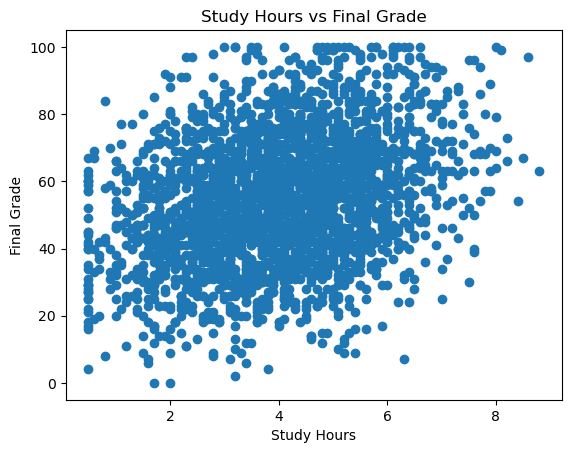

In [20]:
#eda
plt.scatter(data['study_hours_per_day'], data['final_exam_score'])
plt.xlabel('Study Hours')
plt.ylabel('Final Grade')
plt.title('Study Hours vs Final Grade')
plt.show()

In [26]:
#feature engineering
X = data.drop('final_exam_score', axis=1)
y = data['final_exam_score']

In [27]:
#split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
#train the model
model = LinearRegression()
model.fit(X_train, y_train)
#make predictions
y_pred = model.predict(X_test)

In [29]:
#evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')

Mean Squared Error: 35.453069728430634
R^2 Score: 0.9039154361207987


In [38]:
#save the model
import joblib
joblib.dump(model, 'linear_regression_model.pkl')

['linear_regression_model.pkl']

In [39]:
# Rebuild and save model with safe format for cross-version compatibility
import pickle
import json

# Save model using pickle protocol 4 (compatible with Python 3.4+)
with open('linear_regression_model.pkl', 'wb') as f:
    pickle.dump(model, f, protocol=4)

# Also save model metadata for debugging
metadata = {
    'model_type': 'LinearRegression',
    'n_features': model.n_features_in_,
    'r2_score': float(r2),
    'mse': float(mse),
    'training_date': pd.Timestamp.now().isoformat()
}

with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("✅ Model saved successfully with pickle protocol 4")
print(f"Metadata: {metadata}")

✅ Model saved successfully with pickle protocol 4
Metadata: {'model_type': 'LinearRegression', 'n_features': 29, 'r2_score': 0.9039154361207987, 'mse': 35.453069728430634, 'training_date': '2026-05-25T15:00:48.764899'}
